# Part 3 — Prophet Model

## Prophet Model

In [17]:
!pip install prophet -q

In [18]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Aggregate to total weekly sales for Prophet
df_prophet = df.groupby("Date").agg({"Weekly_Sales": "sum"}).reset_index()
df_prophet.columns = ["ds", "y"]

split_date_dt = pd.to_datetime("2012-08-01")
prophet_train = df_prophet[df_prophet["ds"] <  split_date_dt].reset_index(drop=True)
prophet_val   = df_prophet[df_prophet["ds"] >= split_date_dt].reset_index(drop=True)

# Define holiday calendar
holidays = pd.concat([
    pd.DataFrame({"holiday": "black_friday",
                  "ds": pd.to_datetime(["2010-11-26", "2011-11-25", "2012-11-23"]),
                  "lower_window": -1, "upper_window": 1}),
    pd.DataFrame({"holiday": "christmas",
                  "ds": pd.to_datetime(["2010-12-24", "2011-12-24", "2012-12-24"]),
                  "lower_window": -1, "upper_window": 1}),
], ignore_index=True)

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    holidays=holidays,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.05
)
prophet_model.fit(prophet_train)

# Predictions
prophet_train_pred = prophet_model.predict(prophet_train[["ds"]])["yhat"].values
prophet_val_pred   = prophet_model.predict(prophet_val[["ds"]])["yhat"].values

prophet_train_rmse = np.sqrt(mean_squared_error(prophet_train["y"], prophet_train_pred))
prophet_val_rmse   = np.sqrt(mean_squared_error(prophet_val["y"],   prophet_val_pred))
prophet_val_mae    = mean_absolute_error(prophet_val["y"], prophet_val_pred)
prophet_val_r2     = r2_score(prophet_val["y"], prophet_val_pred)

print(f"Prophet â€” Train RMSE: ${prophet_train_rmse:,.2f}")
print(f"Prophet â€” Val   RMSE: ${prophet_val_rmse:,.2f}")
print(f"Prophet â€” Val   MAE : ${prophet_val_mae:,.2f}")
print(f"Prophet â€” Val   RÂ²  : {prophet_val_r2:.4f}")

15:42:07 - cmdstanpy - INFO - Chain [1] start processing
15:42:07 - cmdstanpy - INFO - Chain [1] done processing


Prophet â€” Train RMSE: $1,756,975.99
Prophet â€” Val   RMSE: $1,413,464.58
Prophet â€” Val   MAE : $1,207,509.84
Prophet â€” Val   RÂ²  : 0.0780


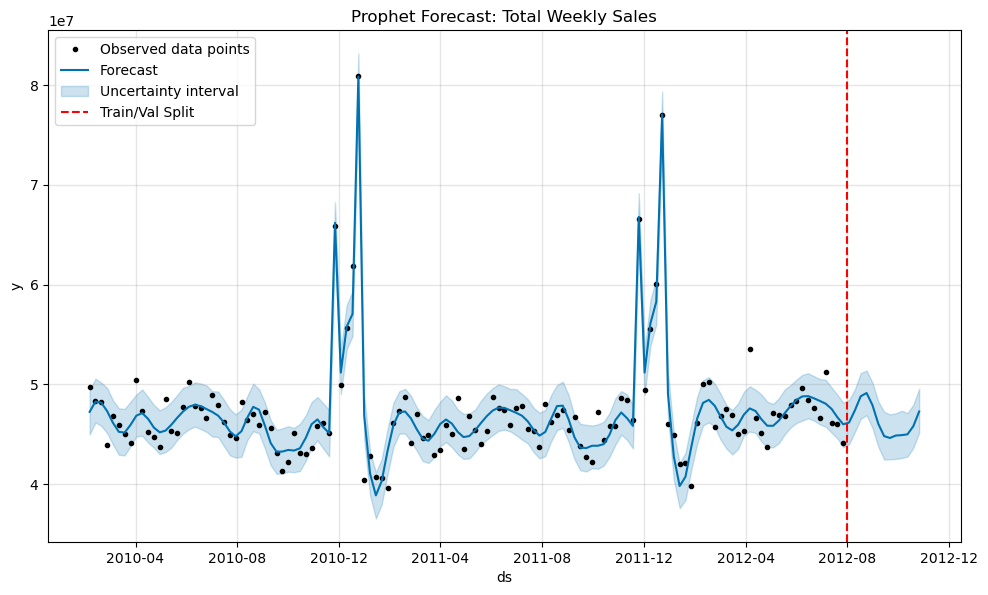

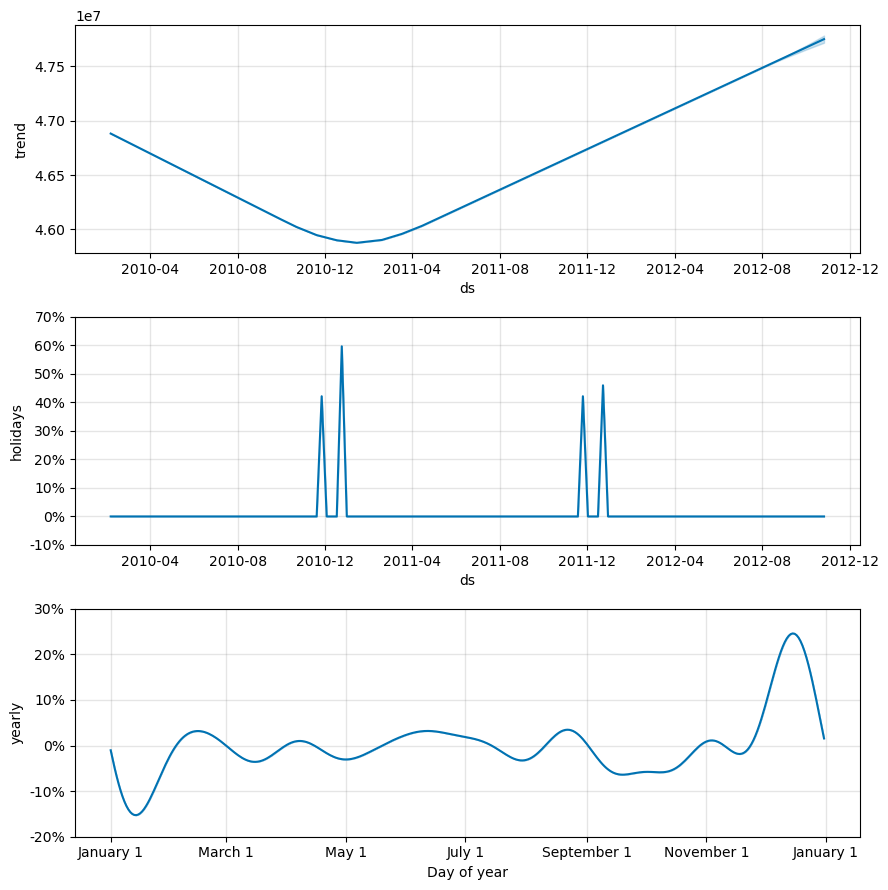

In [19]:
# Prophet forecast plot
prophet_forecast = prophet_model.predict(
    pd.concat([prophet_train[["ds"]], prophet_val[["ds"]]], ignore_index=True)
)
fig1 = prophet_model.plot(prophet_forecast)
plt.title("Prophet Forecast: Total Weekly Sales")
plt.axvline(x=split_date_dt, color="red", linestyle="--", label="Train/Val Split")
plt.legend()
plt.show()

# Decomposed components
fig2 = prophet_model.plot_components(prophet_forecast)
plt.show()